In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/Walmart DataSet.csv")

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df.shape

(6435, 8)

In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [ ]:
#convet date to Date data type
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

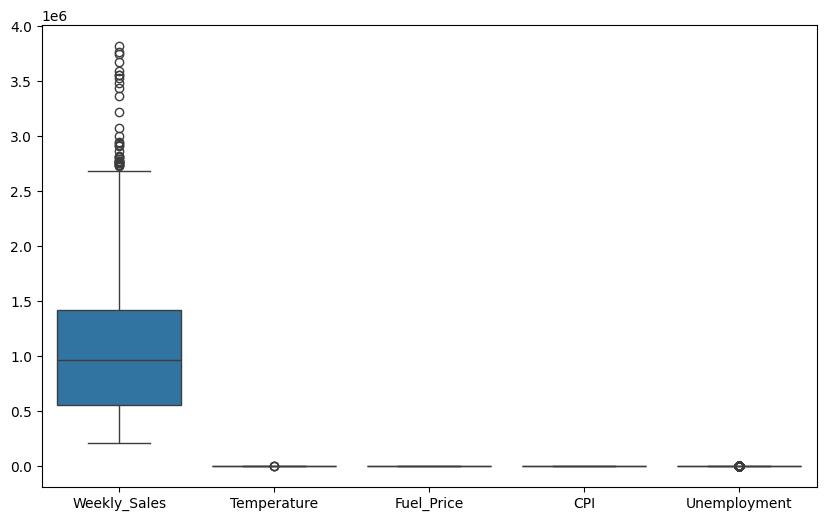

In [ ]:
##Check Outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']])
plt.show()

In [ ]:
#Outlier Removal
Q1= df['Weekly_Sales'].quantile(0.25)
Q3=df['Weekly_Sales'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

df = df[(df['Weekly_Sales'] >=lower) & (df['Weekly_Sales'] <=upper)]


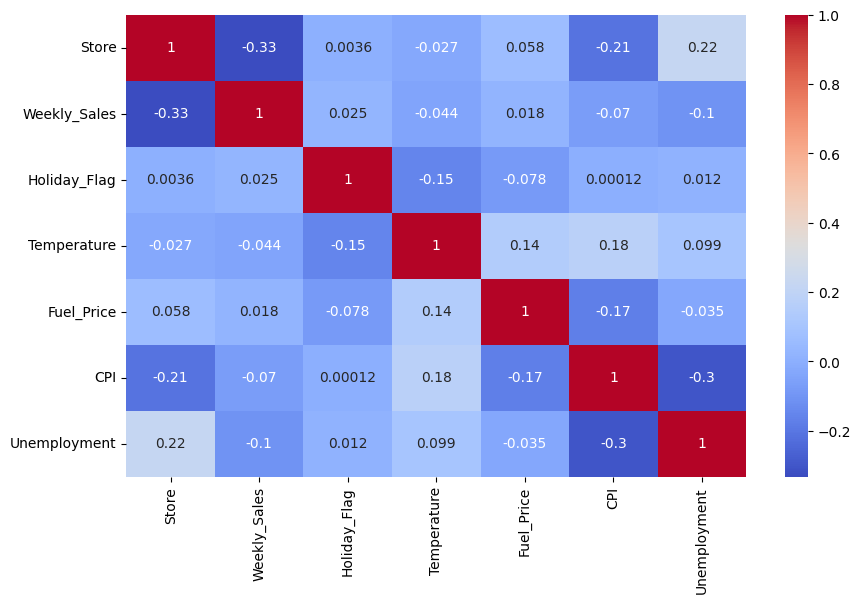

In [ ]:
#Corelation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
                    annot=True,
                    cmap='coolwarm')
plt.show()

** Question (a)
Is Weekly Sales affected by Unemployment? **

Overall correlation

In [ ]:
corr= df['Weekly_Sales'].corr(df['Unemployment'])
print(corr)

-0.10429750912578388


**Store-wise**

In [ ]:
store_corr=df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment']))
store_corr

,0
Store,
1,-0.097955
2,0.054288
3,-0.230413
4,-0.639563
5,-0.207043
6,0.016833
7,-0.165382
8,-0.052580
9,-0.191534


In [ ]:
store_corr.sort_values()

,0
Store,
38,-0.785290
44,-0.780076
4,-0.639563
13,-0.400254
39,-0.384681
42,-0.356355
41,-0.350630
17,-0.263600
3,-0.230413


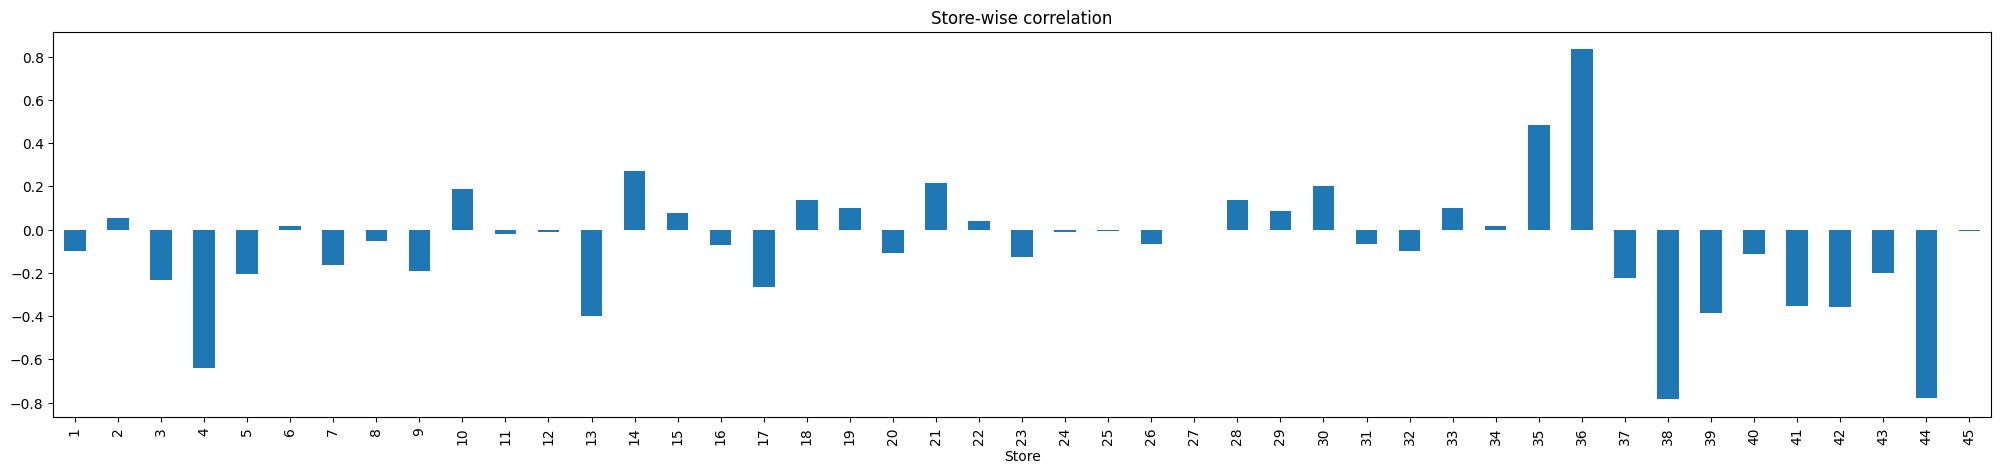

In [ ]:
store_corr.plot(kind='bar',figsize=(25,5))
plt.title('Store-wise correlation')
plt.show()

Conclusion

Negative correlation indicates unemployment decreases sales.

Stores having highest negative correlation suffer the most.

**Question (b)
Seasonal Trend**

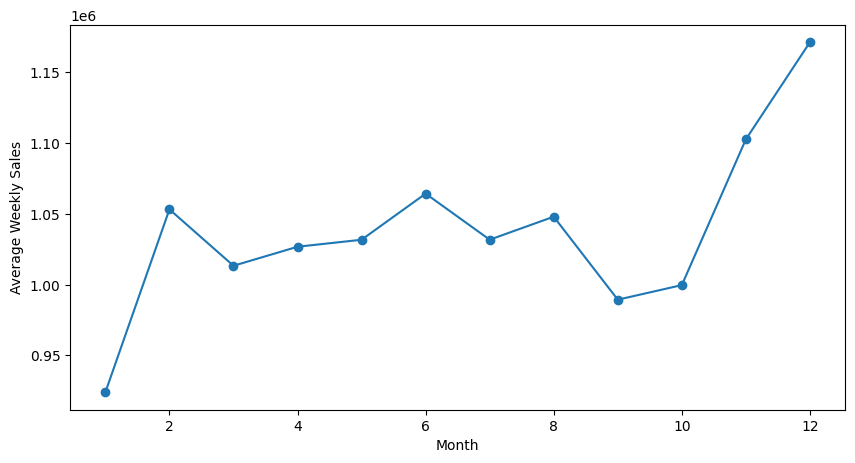

In [ ]:
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(marker='o',figsize=(10,5))
plt.ylabel('Average Weekly Sales')
plt.show()

Holiday comparison

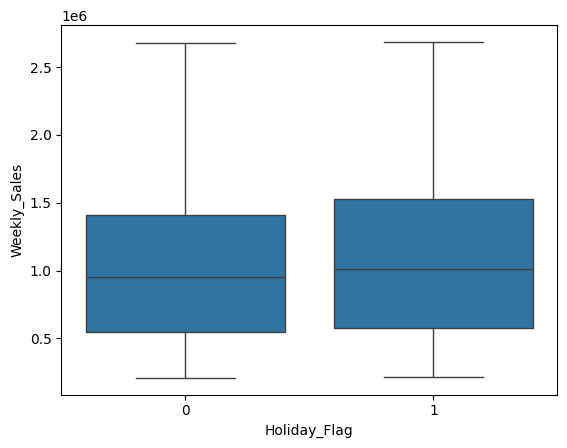

In [ ]:
sns.boxplot(x='Holiday_Flag',y='Weekly_Sales',data=df)
plt.show()

Conclusion

Usually sales peak during:

Thanksgiving
Christmas
New Year

Holiday weeks generally show higher sales.

**Question (c)
Temperature vs Weekly Sales**

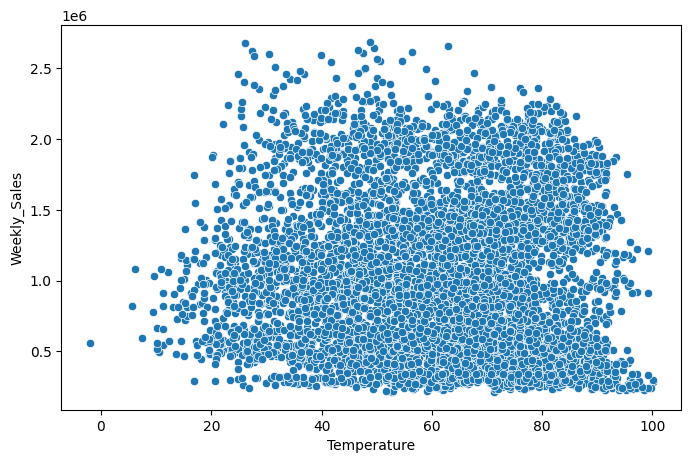

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Temperature',
                y='Weekly_Sales',
                data=df)

plt.show()

In [ ]:
print(df['Temperature'].corr(df['Weekly_Sales']))

-0.04434018335109511


**Question (d)
CPI Effect**

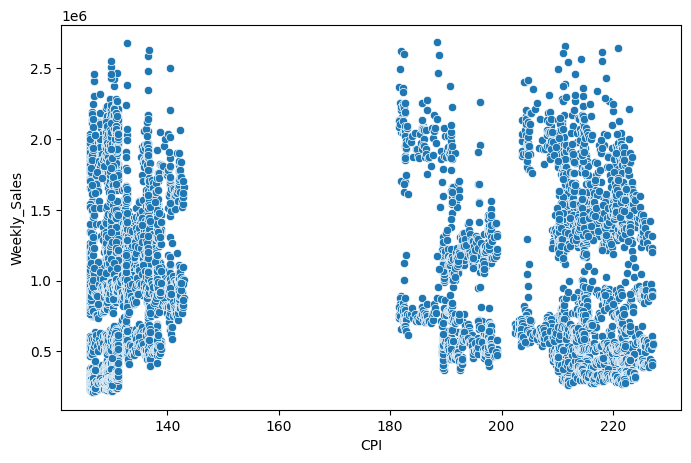

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='CPI',
                y='Weekly_Sales',
                data=df)

plt.show()

**Question (e)
Top Performing Stores**

In [ ]:
top_store= df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_store.head(10)

,Weekly_Sales
Store,
4,2.810352e+08
20,2.800237e+08
14,2.761276e+08
2,2.687221e+08
13,2.682025e+08
10,2.556789e+08
27,2.480387e+08
1,2.224028e+08
6,2.210286e+08


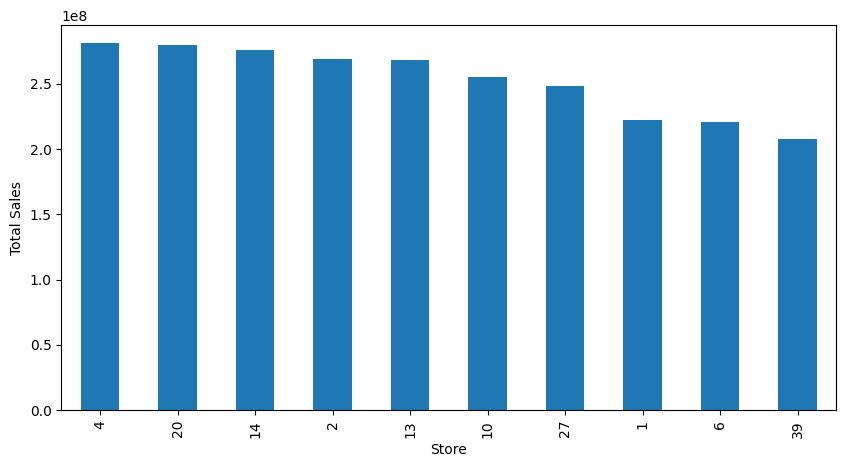

In [ ]:
top_store.head(10).plot(kind='bar',
                        figsize=(10,5))

plt.ylabel("Total Sales")

plt.show()

**Question (f)
Worst Performing Store**

In [ ]:
lowest = top_store.idxmin()

highest = top_store.idxmax()

print("Highest Store :", highest)

print("Lowest Store :", lowest)

Highest Store : 4
Lowest Store : 33


Difference

In [ ]:
difference = top_store.max()-top_store.min()

print(difference)

243875002.96


**Predictive Modeling
Prepare Data**

In [ ]:
forecast_df = df.copy()

forecast_df['Week'] = np.arange(len(forecast_df))

In [ ]:
x=forecast_df[['Week']]
y=forecast_df['Weekly_Sales']
model = LinearRegression()
model.fit(x,y)

LinearRegression()

**Predict Next 12 Weeks**

In [ ]:
future = pd.DataFrame({'Week':np.arange(len(forecast_df),len(forecast_df)+12)})
future['Predicted_Sales']=model.predict(future)
future

,Week,Predicted_Sales
0,6401,721777.759642
1,6402,721679.555145
2,6403,721581.350649
3,6404,721483.146152
4,6405,721384.941655
5,6406,721286.737159
6,6407,721188.532662
7,6408,721090.328165
8,6409,720992.123668
9,6410,720893.919172


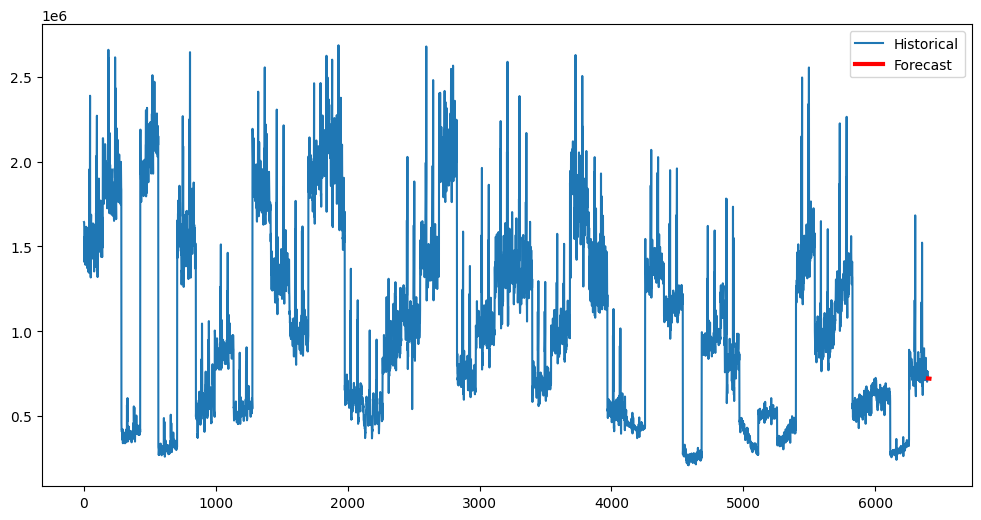

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(forecast_df['Week'],
         forecast_df['Weekly_Sales'],
         label='Historical')

plt.plot(future['Week'],
         future['Predicted_Sales'],
         color='red',
         linewidth=3,
         label='Forecast')

plt.legend()

plt.show()

**Final Conclusions (for Report)**

*   Weekly Sales generally have a negative relationship with unemployment. Stores with the strongest negative correlation are the most affected.
*   Sales exhibit a seasonal pattern, with peaks around major holiday periods such as Thanksgiving and Christmas.
*  Temperature usually has a weak impact on sales compared with economic and seasonal factors.
* Consumer Price Index (CPI) shows a measurable relationship with sales, though the strength varies across stores.

* Historical sales identify the top-performing and lowest-performing stores, and the total sales difference between them quantifies the performance gap.




**ARIMA Model**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

In [ ]:
df = pd.read_csv("Walmart DataSet.csv")

df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

df = df.sort_values('Date')

**Forecast Store-wise**
Example for Store 1

In [ ]:
store1 = df[df['Store']==1]

sales = store1[['Date','Weekly_Sales']]

sales.set_index('Date', inplace=True)

sales.head()

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68


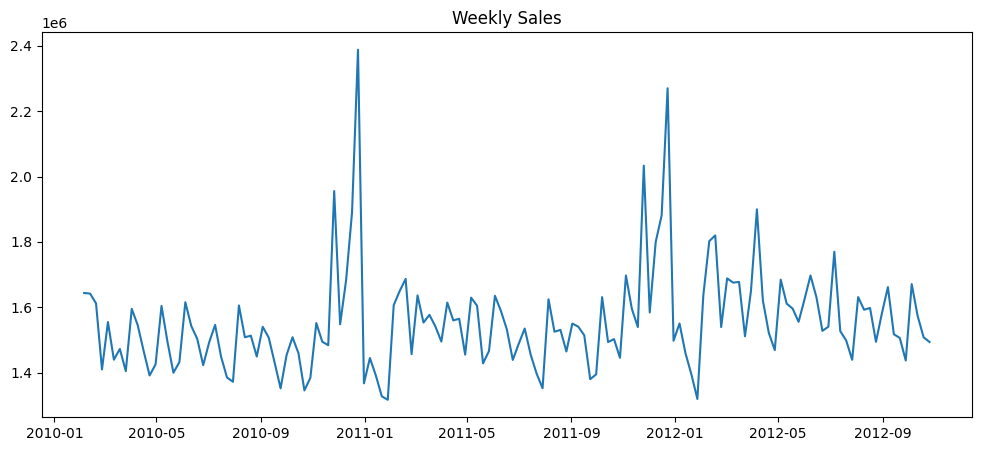

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(sales)

plt.title("Weekly Sales")

plt.show()

**Build ARIMA**

In [ ]:
model = ARIMA(sales,
              order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1901.452
Date:                Wed, 22 Jul 2026   AIC                           3814.905
Time:                        09:04:03   BIC                           3832.640
Sample:                    02-05-2010   HQIC                          3822.112
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3150      0.041     -7.624      0.000      -0.396      -0.234
ar.L2         -0.2848      0.044     -6.438      0.000      -0.371      -0.198
ar.L3         -0.2592      0.057     -4.547      0.0

**Forecast Next 12 Weeks**

In [ ]:
forecast = model_fit.forecast(steps=12)

forecast

,predicted_mean
2012-11-02,1.565441e+06
2012-11-09,1.524021e+06
2012-11-16,1.530963e+06
2012-11-23,1.530657e+06
2012-11-30,1.545705e+06
2012-12-07,1.526392e+06
2012-12-14,1.534726e+06
2012-12-21,1.532667e+06
2012-12-28,1.536849e+06
2013-01-04,1.530657e+06


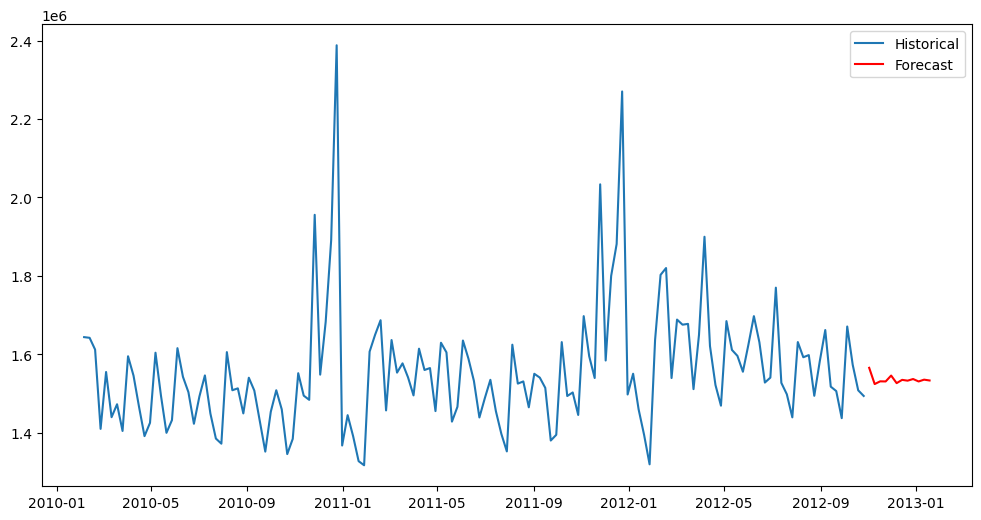

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(sales,label="Historical")

plt.plot(forecast.index,
         forecast,
         color='red',
         label='Forecast')

plt.legend()

plt.show()

**Forecast Every Store**

In [ ]:
stores = df['Store'].unique()

forecast_result = {}

for store in stores:

    temp = df[df['Store']==store]

    temp = temp.sort_values('Date')

    ts = temp.set_index('Date')['Weekly_Sales']

    model = ARIMA(ts,
                  order=(5,1,0))

    fit = model.fit()

    pred = fit.forecast(12)

    forecast_result[store] = pred

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

**Display Forecast**

In [ ]:
for store,pred in forecast_result.items():

    print("\nStore :",store)

    print(pred)


Store : 1
2012-11-02    1.565441e+06
2012-11-09    1.524021e+06
2012-11-16    1.530963e+06
2012-11-23    1.530657e+06
2012-11-30    1.545705e+06
2012-12-07    1.526392e+06
2012-12-14    1.534726e+06
2012-12-21    1.532667e+06
2012-12-28    1.536849e+06
2013-01-04    1.530657e+06
2013-01-11    1.535251e+06
2013-01-18    1.533146e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64

Store : 10
2012-11-02    1.745933e+06
2012-11-09    1.725798e+06
2012-11-16    1.738612e+06
2012-11-23    1.736030e+06
2012-11-30    1.736077e+06
2012-12-07    1.732660e+06
2012-12-14    1.738393e+06
2012-12-21    1.735128e+06
2012-12-28    1.735891e+06
2013-01-04    1.735107e+06
2013-01-11    1.736726e+06
2013-01-18    1.735095e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64

Store : 37
2012-11-02    537274.492995
2012-11-09    535954.930947
2012-11-16    538149.716230
2012-11-23    536266.258075
2012-11-30    537129.565013
2012-12-07    536911.052053
2012-12-14    537049.690145
2012-12-21    536889.